# iNDI production - nucleus segmentation testing
Marianita completed image aquisition of the first 23 plates of data and everything has been copied to data/CARDPB2/iNDI\
Alena has been working on metadata aggregation and samplesheets\

## Important aquisition notes
Generally, imaging went well, but some wells from plates (and at least one whole plate) were aquired on different days, be sure to include aquisition dates in data metrics to test whether imaging date had any effect on phenotypes\
Marianita also noticed a registration issue with at least two of the imaging channels (LAMP1 and EEA1) resulting in a missalignment of several pixels. The cause of misalignment is not clear and we are uncertain how consistent it is - it might be worth it to run correlation of these channels across all images to see if there was a shift in correlation relative to time?

## Experimental metadata extraction

### Metadata from epxerimental design

In [1]:
# load in Alena's CSVs
import pandas as pd

test = pd.read_csv("/data/CARDPB2/iNDI/Production/metadata/all_automated_plates_combined.csv")
test

,iNDI_Plate_ID,Well_ID,Genotype_Name,JAX_ID,Cell_Line_ID,Layout,Folder_ID
0,INDI00026D,A01,HNRNPA1 D262N HOM,JAX_ID_JIPSC001038,JAX_ID_JIPSC001038\nHNRNPA1 D262N HOM\nLow cou...,Plate026,c6a92be6-a13a-4957-a62d-9f99961c903f
1,INDI00026D,A02,HNRNPA1 D262N HOM,JAX_ID_JIPSC001038,JAX_ID_JIPSC001038\nHNRNPA1 D262N HOM\nLow cou...,Plate026,c6a92be6-a13a-4957-a62d-9f99961c903f
2,INDI00026D,A03,HNRNPA1 D262N REV,JAX_ID_JIPSC001042,JAX_ID_JIPSC001042\nHNRNPA1 D262N REV\nLow cou...,Plate026,c6a92be6-a13a-4957-a62d-9f99961c903f
3,INDI00026D,A04,HNRNPA1 D262N HOM,JAX_ID_JIPSC001038,JAX_ID_JIPSC001038\nHNRNPA1 D262N HOM\nLow cou...,Plate026,c6a92be6-a13a-4957-a62d-9f99961c903f
4,INDI00026D,A05,PFN1 C71G HET,JAX_ID_JIPSC001034,JAX_ID_JIPSC001034\nPFN1 C71G HET\nLow counts ...,Plate026,c6a92be6-a13a-4957-a62d-9f99961c903f
...,...,...,...,...,...,...,...
4741,INDI00039D,P20,SNCB P123H HOM,JAX_ID_JIPSC001026,JAX_ID_JIPSC001026\nSNCB P123H HOM,Plate039,07fc5da6-9d7d-4c97-858b-4b76df1859a5
4742,INDI00039D,P21,SNCB P123H HET,JAX_ID_JIPSC001028,JAX_ID_JIPSC001028\nSNCB P123H HET\nLost - To ...,Plate039,07fc5da6-9d7d-4c97-858b-4b76df1859a5
4743,INDI00039D,P22,Parental (P9) ID:6930,JAX_ID_JIPSC001000,JAX_ID_JIPSC001000\nParental (P9) ID:6930,Plate039,07fc5da6-9d7d-4c97-858b-4b76df1859a5
4744,INDI00039D,P23,APP E693G REV,JAX_ID_JIPSC001102,JAX_ID_JIPSC001102\nAPP E693G REV,Plate039,07fc5da6-9d7d-4c97-858b-4b76df1859a5


### Metadata from Opera Phenix

In [2]:
# Define relevant dictionaries for metatdata

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define pseudocolor mapping rules - helpful to generate images on the fly
pseudocolor_map = {
    "DAPI": "blue",
    "Brightfield": "gray",
    "Alexa 488": "green",
    "Alexa 568": "red",
    "Alexa 647": "magenta"
}

# Define pseudocolor mapping rules for matplotlib - helpful to generate images on the fly
mpl_colormaps = {
    "blue": LinearSegmentedColormap.from_list("black_blue", [(0, 0, 0), (0, 0, 1)]),
    "green": LinearSegmentedColormap.from_list("black_green", [(0, 0, 0), (0, 1, 0)]),
    "red": LinearSegmentedColormap.from_list("black_red", [(0, 0, 0), (1, 0, 0)]),
    "magenta": LinearSegmentedColormap.from_list("black_magenta", [(0, 0, 0), (1, 0, 1)]),
    "gray": LinearSegmentedColormap.from_list("black_gray", [(0, 0, 0), (1, 1, 1)])
}

In [ ]:
import xml.etree.ElementTree as ET
from pathlib import Path
import pandas as pd

028ebee9-afaf-4ff8-b435-af11714285dc


# 0c2035b2-6f9d-45b0-919b-94abbd4ad465
tree = ET.parse("/data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45b0-919b-94abbd4ad465/0c2035b2-6f9d-45b0-919b.xml")
OF_dir = Path("/data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45b0-919b-94abbd4ad465/images")
index_tree = ET.parse('/data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45b0-919b-94abbd4ad465/images/index.xml')

root = tree.getroot()

# Namespace mapping
ns = {'h': '43B2A954-E3C3-47E1-B392-6635266B0DD3/HarmonyV7'} # I believe this is consistent between all experiments

# Find elements
measurement_id = root.find('h:MeasurementID', ns).text
date = root.find('h:Date', ns).text
plate = root.find('h:InitialPlateName', ns).text

print("Measurement ID:", measurement_id)
print("Date:", date)
print("Plate:", plate)

root = index_tree.getroot()

# Find elements
plate_id = root.find('.//h:PlateID', ns).text
x_res = float(root.find('.//h:ImageResolutionX', ns).text) * 1e6
y_res = float(root.find('.//h:ImageResolutionY', ns).text) * 1e6

print("Plate:", plate_id)
print(f"X resolution: {x_res} µm")
print(f"Y resolution: {y_res} µm")

channels = []

# Find the Map element that contains channel info entries
for map_el in root.findall(".//h:Map", ns):
    # Check first entry if it has a ChannelName child
    first_entry = map_el.find("h:Entry", ns)
    if first_entry is not None and first_entry.find("h:ChannelName", ns) is not None:
        # Found the Map with channel entries
        for entry in map_el.findall("h:Entry", ns):
            ch_id = entry.attrib.get("ChannelID")
            ch_name = entry.find("h:ChannelName", ns).text
            ch_type = entry.find("h:ChannelType", ns).text if entry.find("h:ChannelType", ns) is not None else None
            excitation = entry.find("h:MainExcitationWavelength", ns).text if entry.find("h:MainExcitationWavelength", ns) is not None else None
            emission = entry.find("h:MainEmissionWavelength", ns).text if entry.find("h:MainEmissionWavelength", ns) is not None else None

            channels.append({
                "ChannelID": int(ch_id) if ch_id is not None else None,
                "Channel_name": ch_name,
                "Type": ch_type,
                "Excitation_nm": excitation,
                "Emission_nm": emission
            })
        break  

# Convert to DataFrame
channel_df = pd.DataFrame(channels).sort_values('ChannelID').reset_index(drop=True)
print(channel_df)

channel_df["Pseudocolor"] = channel_df["Channel_name"].map(pseudocolor_map).fillna("gray")
channel_df["MPL_colormap"] = channel_df["Pseudocolor"].str.lower().map(mpl_colormaps)
channel_df["Measurement_ID"] = measurement_id
channel_df["Measurement_date"] = date
channel_df["Plate_ID"] = plate_id
channel_df["res_x"] = x_res
channel_df["res_y"] = y_res

print(channel_df)

Measurement ID: 0c2035b2-6f9d-45b0-919b-94abbd4ad465
Date: 2026-02-16T09:16:05.6991184-05:00
Plate: INDIMS0000
Plate: INDIMS0000
X resolution: 0.09418670872212731 µm
Y resolution: 0.09418670872212731 µm
   ChannelID Channel_name          Type Excitation_nm Emission_nm
0          1         DAPI  Fluorescence           375         456
1          2    Alexa 647  Fluorescence           640         706
2          3    Alexa 488  Fluorescence           488         522
3          4    Alexa 568  Fluorescence           561         599
   ChannelID Channel_name          Type Excitation_nm Emission_nm Pseudocolor  \
0          1         DAPI  Fluorescence           375         456        blue   
1          2    Alexa 647  Fluorescence           640         706     magenta   
2          3    Alexa 488  Fluorescence           488         522       green   
3          4    Alexa 568  Fluorescence           561         599         red   

                                        MPL_colormap  \
0  <m

In [ ]:
# wrap above in a function
# get list of folders that we care about (plates)
# batch for all plates to generate a larger metadata file

## Plate summary

In [ ]:
import re
import pandas as pd

# Collect all .tiff files
files = sorted([f for f in OF_dir.rglob('*') if f.suffix.lower() in ['.tiff']])

# Define a function to parse the filename
def parse_filename(name):
    match = re.match(r"r(\d+)c(\d+)f(\d+)p(\d+)-ch(\d+)t(\d+)", name)
    if match:
        return [int(g) for g in match.groups()]
    else:
        return [None] * 6  # Fallback if filename doesn't match

# Create a DataFrame with full path and relative subdirectory
df = pd.DataFrame({
    'filepath': files,
    'filename': [f.name for f in files], 
    'subdirectory': [f.parent.relative_to(OF_dir) for f in files]
})

# Extract metadata from filenames
df[['Row', 'Column', 'Frame', 'Plane', 'ChannelID', 'Time']] = df['filename'].apply(
    lambda x: pd.Series(parse_filename(x))
)

print(df.head())

                                            filepath  \
0  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
1  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
2  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
3  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
4  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   

                    filename subdirectory  Row  Column  Frame  Plane  \
0  r02c03f01p01-ch01t01.tiff       r02c03    2       3      1      1   
1  r02c03f01p01-ch02t01.tiff       r02c03    2       3      1      1   
2  r02c03f01p01-ch03t01.tiff       r02c03    2       3      1      1   
3  r02c03f01p01-ch04t01.tiff       r02c03    2       3      1      1   
4  r02c03f02p01-ch01t01.tiff       r02c03    2       3      2      1   

   ChannelID  Time  
0          1     1  
1          2     1  
2          3     1  
3          4     1  
4          1     1  
                                            filepath  \
0  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-4

In [ ]:
merged_ChannelID_df = pd.merge(df, channel_df, on="ChannelID")
print(merged_ChannelID_df)

                                            filepath  \
0  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
1  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
2  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
3  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
4  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   

                    filename subdirectory  Row  Column  Frame  Plane  \
0  r02c03f01p01-ch01t01.tiff       r02c03    2       3      1      1   
1  r02c03f01p01-ch02t01.tiff       r02c03    2       3      1      1   
2  r02c03f01p01-ch03t01.tiff       r02c03    2       3      1      1   
3  r02c03f01p01-ch04t01.tiff       r02c03    2       3      1      1   
4  r02c03f02p01-ch01t01.tiff       r02c03    2       3      2      1   

   ChannelID  Time Channel_name          Type Excitation_nm Emission_nm  \
0          1     1         DAPI  Fluorescence           375         456   
1          2     1    Alexa 647  Fluorescence           640         706   
2    

In [ ]:
summary = {
    "wells": merged_ChannelID_df[['Row', 'Column']].drop_duplicates().shape[0],
    "channels": merged_ChannelID_df['ChannelID'].nunique(),
    "z_planes": merged_ChannelID_df['Plane'].nunique(),
    "frames": merged_ChannelID_df['Frame'].nunique(),
    "timepoints": merged_ChannelID_df['Time'].nunique(),
}

print(summary)

print(f"""
Experiment ID: {measurement_id}
Plate ID: {plate}
Wells imaged: {summary["wells"]}
Frames per well: {summary["frames"]}
Channels per image: {summary["channels"]}
Z-slices per image: {summary["z_planes"]}
Timepoints per image: {summary["timepoints"]}
""")

{'wells': 112, 'channels': 4, 'z_planes': 1, 'frames': 35, 'timepoints': 1}

Experiment ID: 0c2035b2-6f9d-45b0-919b-94abbd4ad465
Plate ID: INDIMS0000
Wells imaged: 112
Frames per well: 35
Channels per image: 4
Z-slices per image: 1
Timepoints per image: 1



In [ ]:
# generate an plot of a plate to show wells that have data

## Validating nucleus segmentation

In [40]:
# subset for an image

subset = merged_ChannelID_df[
    (merged_ChannelID_df['Row'] == 11) & 
    (merged_ChannelID_df['Column'] == 4) & 
    (merged_ChannelID_df['Frame'] == 8)]

print(subset)

                                                filepath  \
10248  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
10249  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
10250  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   
10251  /data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45...   

                        filename subdirectory  Row  Column  Frame  Plane  \
10248  r11c04f08p01-ch01t01.tiff       r11c04   11       4      8      1   
10249  r11c04f08p01-ch02t01.tiff       r11c04   11       4      8      1   
10250  r11c04f08p01-ch03t01.tiff       r11c04   11       4      8      1   
10251  r11c04f08p01-ch04t01.tiff       r11c04   11       4      8      1   

       ChannelID  Time Channel_name          Type Excitation_nm Emission_nm  \
10248          1     1         DAPI  Fluorescence           375         456   
10249          2     1    Alexa 647  Fluorescence           640         706   
10250          3     1    Alexa 488  Fluorescence           488         522   
10

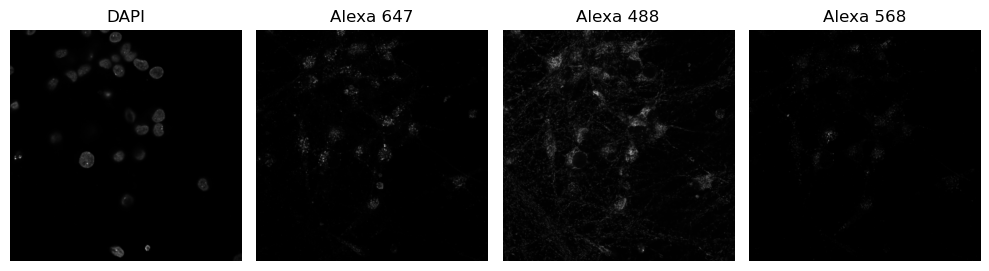

In [41]:
# view image for validation

import matplotlib.pyplot as plt
import tifffile

filepaths = subset["filepath"]
channel_names = subset["Channel_name"]

fig, axes = plt.subplots(1, 4, figsize=(10, 20))

for ax, path, name in zip(axes.ravel(), filepaths, channel_names):
    img = tifffile.imread(path)
    ax.imshow(img, cmap="gray") 
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
#plt.savefig("r14c07f217p01-ch01t01.png", bbox_inches="tight", pad_inches=0, dpi=200)
plt.show()

In [42]:
nuc_path = subset[subset["Channel_name"] == "DAPI"]["filepath"].iloc[0]
print(nuc_path)

nuc_test = tifffile.imread(nuc_path)
print(nuc_test)

/data/CARDPB2/iNDI/Production/0c2035b2-6f9d-45b0-919b-94abbd4ad465/images/r11c04/r11c04f08p01-ch01t01.tiff
[[ 138  150  137 ...  125  120  119]
 [ 150  145  136 ...  116  120  120]
 [ 137  136  127 ...  121  122  118]
 ...
 [ 190  179  178 ... 1492 1381 1296]
 [ 196  179  181 ... 1146 1082 1003]
 [ 187  178  191 ...  881  874  807]]


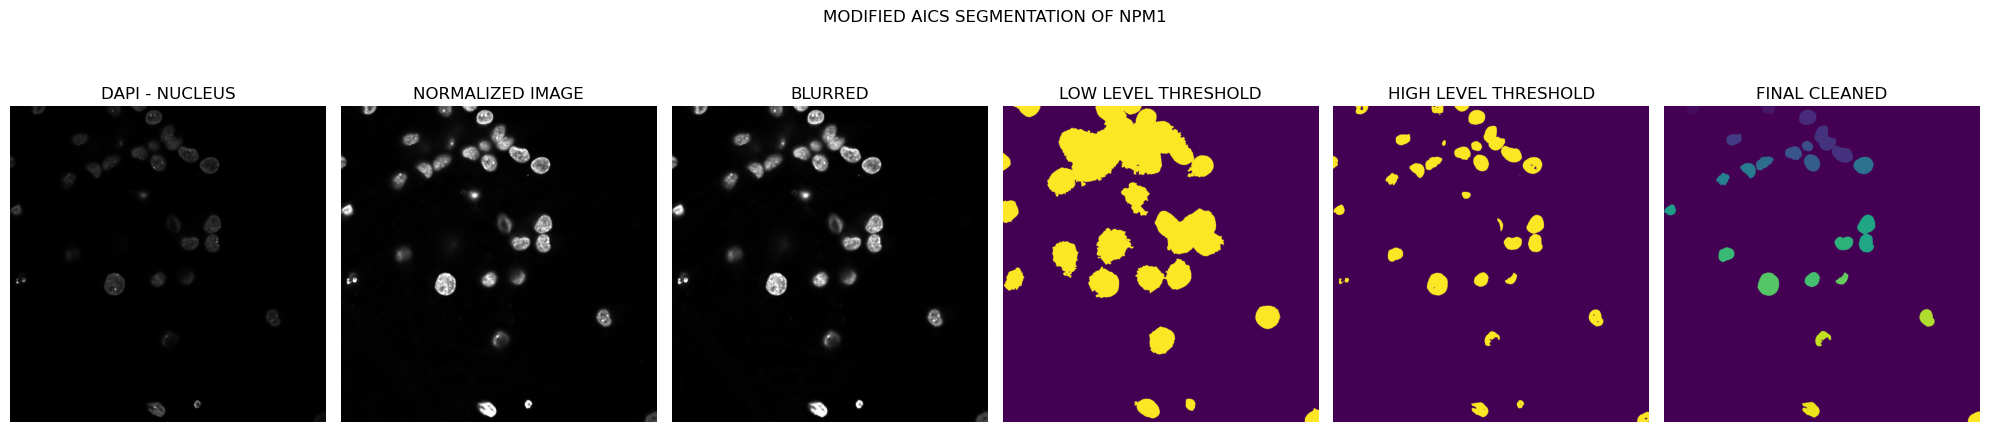

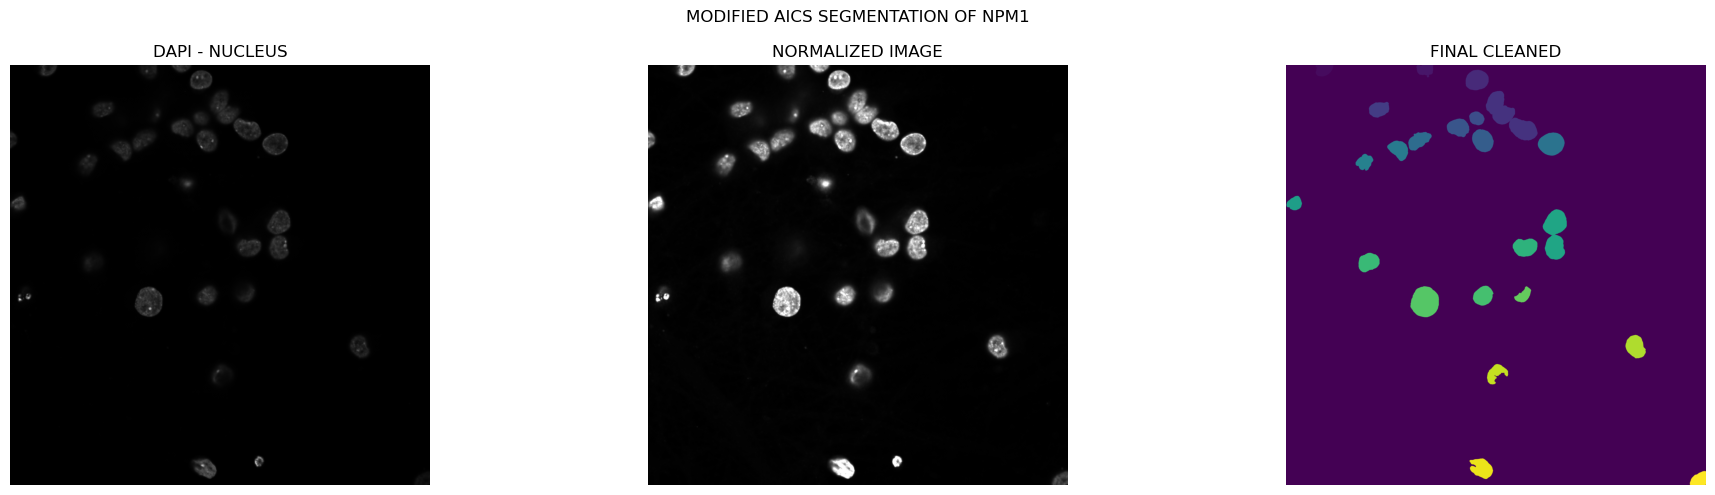

In [43]:
from scipy.ndimage import gaussian_laplace
from skimage import filters, morphology
from scipy import ndimage as ndi
import numpy as np
from scipy.stats import norm

nuc = nuc_test

# Paramaters - same as ACIS standard
intensity_scaling_param = [1, 7] # may need to update this for the opera phenix data
blur_sigma = 1
min_area = 3500

# Normalize image
#image_norm = (nuc - np.min(nuc)) / (np.max(nuc) - np.min(nuc))

# Normalize to normal distribution
m, s = norm.fit(nuc.flatten())
stretch_min = max(m - intensity_scaling_param[0] * s, nuc.min())
stretch_max = min(m + intensity_scaling_param[1] * s, nuc.max())
nuc_stretch = np.clip(nuc, stretch_min, stretch_max)
image_norm = (nuc_stretch - stretch_min) / (stretch_max - stretch_min)

# Blur image
blurred = filters.gaussian(image_norm, sigma=blur_sigma)

# step 1: low level thresholding
triangle_cutoff = filters.threshold_triangle(blurred)
global_median_cutoff = np.percentile(blurred, 50)

th_low_cutoff = (triangle_cutoff + global_median_cutoff) / 2
img_low_level = blurred > th_low_cutoff

img_low_level = morphology.remove_small_objects(img_low_level, min_size=min_area, connectivity=1, out=img_low_level)
img_low_level = morphology.dilation(img_low_level, footprint=morphology.disk(2))

# step 2: high level thresholding
otsu_cutoff = 0.333 * filters.threshold_otsu(blurred)
img_high_level = np.zeros_like(img_low_level)
lab_low, num_obj = morphology.label(img_low_level, return_num=True, connectivity=1)
for idx in range(num_obj):
    single_obj = lab_low == (idx + 1)
    local_otsu = filters.threshold_otsu(blurred[single_obj])
    if local_otsu > otsu_cutoff:
        img_high_level[np.logical_and(blurred > 0.98 * local_otsu, single_obj)] = 1

filled = ndi.binary_fill_holes(img_high_level)
filled = morphology.dilation(filled, footprint=morphology.disk(2))
labeled_filled = morphology.label(filled, connectivity=1)
nuc_seg = morphology.remove_small_objects(labeled_filled, min_size=min_area)
#nuc_seg = nuc_seg > 0  # binary mask again

fig, axs = plt.subplots(1, 6, figsize=(20, 5))
fig.suptitle("MODIFIED AICS SEGMENTATION OF NPM1")

axs[0].imshow(nuc, cmap='gray') 
axs[0].set_title("DAPI - NUCLEUS")
axs[0].axis("off")

axs[1].imshow(image_norm, cmap='gray')
axs[1].set_title("NORMALIZED IMAGE")
axs[1].axis("off")

axs[2].imshow(blurred, cmap='gray')
axs[2].set_title("BLURRED")
axs[2].axis("off")

axs[3].imshow(img_low_level)
axs[3].set_title("LOW LEVEL THRESHOLD")
axs[3].axis("off")

axs[4].imshow(img_high_level)
axs[4].set_title("HIGH LEVEL THRESHOLD")
axs[4].axis("off")

axs[5].imshow(nuc_seg)
axs[5].set_title("FINAL CLEANED")
axs[5].axis("off")

plt.tight_layout()
#plt.savefig("masks/r02c11f50p01-ch01t01.png", bbox_inches="tight", pad_inches=0, dpi=200)
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("MODIFIED AICS SEGMENTATION OF NPM1")

axs[0].imshow(nuc, cmap='gray') 
axs[0].set_title("DAPI - NUCLEUS")
axs[0].axis("off")

axs[1].imshow(image_norm, cmap='gray')
axs[1].set_title("NORMALIZED IMAGE")
axs[1].axis("off")

axs[2].imshow(nuc_seg)
axs[2].set_title("FINAL CLEANED")
axs[2].axis("off")

plt.tight_layout()
#plt.savefig("masks/r02c11f50p01-ch01t01.png", bbox_inches="tight", pad_inches=0, dpi=200)
plt.show()

In [44]:
from skimage.measure import regionprops_table
import pandas as pd
import os

# Use original or normalized fluorescence image (same shape as nuc_seg)
# image = your raw or normalized image used for segmentation

props = regionprops_table(
    label_image=nuc_seg,
    intensity_image=nuc,
    properties=(
        'label',
        'area',
        'mean_intensity',
        'max_intensity',
        'min_intensity',
        'std_intensity',
        'centroid', # 0 == Y, 1 == X
        'eccentricity',
        'solidity',
        'perimeter',
        'feret_diameter_max',
        'orientation',
        'major_axis_length',
        'minor_axis_length'
    )
)

df_props = pd.DataFrame(props)

# Add image name column
df_props['filename'] = os.path.basename(path)

print(df_props.head())

   label     area  mean_intensity  max_intensity  min_intensity  \
0      1   4332.0     5333.684672        10974.0         1970.0   
1      2   4143.0     4234.889693        13234.0         2207.0   
2      4   9963.0     6673.907357        19540.0         1078.0   
3      5  28249.0     5880.295267        17183.0         1039.0   
4      6   6562.0     4638.787565        11837.0         1806.0   

   std_intensity  centroid-0   centroid-1  eccentricity  solidity   perimeter  \
0    1716.008073   25.484995   193.828486      0.760256  0.964381  276.509668   
1    1354.672054   25.026309   715.203717      0.758005  0.925603  286.752309   
2    2311.829701   77.644786   981.714243      0.524824  0.988197  372.534055   
3    1945.756865  269.557259  1150.818153      0.944953  0.788528  965.761543   
4    1110.782641  227.808747   478.170680      0.727868  0.968847  318.007143   

   feret_diameter_max  orientation  major_axis_length  minor_axis_length  \
0          100.647901    -1.330206